In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Test (Future)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Concatenate, MultiHeadAttention, GlobalAveragePooling1D, BatchNormalization, Conv1D, MaxPooling1D, Flatten,
)
from tensorflow.keras.layers import Lambda
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, Nadam
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import os
import numpy as np
import pandas as pd
import librosa
from sklearn.decomposition import PCA
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [ ]:
# Audio Feature Extraction: Combine AUDIO.wav, COVAREP.csv, and FORMANT.csv
def extract_audio_features(participant_folder, participant_id):
    # AUDIO.wav features
    audio_file = os.path.join(participant_folder, f"{participant_id}_AUDIO.wav")
    audio_features = []
    if os.path.exists(audio_file):
        y, sr = librosa.load(audio_file, sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        audio_features = np.hstack((np.mean(mfcc.T, axis=0),
                                    np.mean(chroma.T, axis=0),
                                    np.mean(spectral_contrast.T, axis=0)))
    # COVAREP.csv features
    covarep_file = os.path.join(participant_folder, f"{participant_id}_COVAREP.csv")
    covarep_features = []
    if os.path.exists(covarep_file):
        covarep_data = pd.read_csv(covarep_file).fillna(0).values
        covarep_features = np.mean(covarep_data, axis=0)

    # FORMANT.csv features
    formant_file = os.path.join(participant_folder, f"{participant_id}_FORMANT.csv")
    formant_features = []
    if os.path.exists(formant_file):
        formant_data = pd.read_csv(formant_file).fillna(0).values
        formant_features = np.mean(formant_data, axis=0)

    # Combine all audio features
    return np.hstack((audio_features, covarep_features, formant_features))

In [ ]:
# Visual Feature Extraction
def extract_visual_features(participant_folder, participant_id):
    visual_files = [
        f"{participant_id}_CLNF_AUs.txt",
        f"{participant_id}_CLNF_features.txt",
        f"{participant_id}_CLNF_features3D.txt",
        f"{participant_id}_CLNF_gaze.txt",
        f"{participant_id}_CLNF_pose.txt"
    ]
    visual_data = []
    for file in visual_files:
        file_path = os.path.join(participant_folder, file)
        if os.path.exists(file_path):
            try:
                # Read the file, skipping non-numeric data
                data = pd.read_csv(file_path, delimiter=' ', header=None, low_memory=False)
                # Convert all data to numeric, coercing invalid entries to NaN
                numeric_data = pd.to_numeric(data.stack(), errors='coerce').unstack()
                # Drop columns or rows with all NaN values
                numeric_data = numeric_data.dropna(axis=1, how='all')
                numeric_data = numeric_data.dropna(axis=0, how='all')
                visual_data.append(numeric_data.values)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
                continue
    if len(visual_data) > 0:
        visual_data = np.concatenate(visual_data, axis=1)
        return np.nanmean(visual_data, axis=0)  # Compute mean across valid frames
    return np.zeros(100)  # Return zero vector if no valid visual data

In [ ]:
# Textual Feature Extraction using BERT embeddings
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def extract_textual_features(participant_folder, participant_id):
    transcript_file = os.path.join(participant_folder, f"{participant_id}_TRANSCRIPT.csv")
    if os.path.exists(transcript_file):
        try:
            # Baca file TRANSCRIPT.csv dengan delimiter '\t'
            df = pd.read_csv(transcript_file, delimiter='\t')

            # Filter hanya percakapan dari participant
            if 'speaker' in df.columns and 'value' in df.columns:
                participant_text = df[df['speaker'] == 'Participant']['value'].dropna().astype(str).tolist()
                text = ' '.join(participant_text)  # Gabungkan semua teks
            else:
                print(f"Warning: Required columns not found in {transcript_file}. Using empty text.")
                text = ""

            # Ekstrak fitur BERT
            inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=512, padding=True)
            outputs = model(**inputs)
            text_embedding = torch.mean(outputs.last_hidden_state, dim=1).detach().numpy()
            return text_embedding.flatten()
        except Exception as e:
            print(f"Error processing {transcript_file}: {e}")
    return np.zeros(768)  # Jika file tidak ada atau gagal diproses, return vektor nol

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
def load_labels(metadata_path):
    """
    Load labels from a manual CSV file.
    """
    metadata = pd.read_csv(metadata_path)
    label_dict = dict(zip(metadata['participant_id'], metadata['label_biner']))
    return label_dict

In [ ]:
def load_dataset(folder_path, label_dict):
    A = []
    B = []
    C = []
    y = []
    for participant_folder in os.listdir(folder_path):
        participant_id = participant_folder.split('_')[0]
        participant_path = os.path.join(folder_path, participant_folder)

        # Ekstrak fitur
        try:
            audio_features = extract_audio_features(participant_path, participant_id)
            visual_features = extract_visual_features(participant_path, participant_id)
            textual_features = extract_textual_features(participant_path, participant_id)

            # Debug: Cek bentuk fitur individu
            print(f"Participant {participant_id} - Audio shape: {audio_features.shape}")
            print(f"Participant {participant_id} - Visual shape: {visual_features.shape}")
            print(f"Participant {participant_id} - Textual shape: {textual_features.shape}")

            # Tambahkan ke dataset
            A.append(audio_features)
            B.append(visual_features)
            C.append(textual_features)
            y.append(label_dict[int(participant_id)])

        except Exception as e:
            print(f"Error processing participant {participant_id}: {e}")

    return np.array(A), np.array(B), np.array(C), np.array(y)

In [ ]:
base_path = "/content/drive/MyDrive/Multimodal Model Dataset"
train_folder = os.path.join(base_path, "train")
metadata_path = os.path.join(base_path, "binary_Labels.csv")

In [ ]:
label_dict = load_labels(metadata_path)

In [ ]:
audio_data, visual_data, text_data, labels = load_dataset(train_folder, label_dict)

Participant 301 - Audio shape: (111,)
Participant 301 - Visual shape: (5,)
Participant 301 - Textual shape: (768,)
Participant 300 - Audio shape: (111,)
Participant 300 - Visual shape: (5,)
Participant 300 - Textual shape: (768,)
Participant 305 - Audio shape: (111,)
Participant 305 - Visual shape: (5,)
Participant 305 - Textual shape: (768,)
Participant 307 - Audio shape: (111,)
Participant 307 - Visual shape: (5,)
Participant 307 - Textual shape: (768,)
Participant 310 - Audio shape: (111,)
Participant 310 - Visual shape: (5,)
Participant 310 - Textual shape: (768,)
Participant 312 - Audio shape: (111,)
Participant 312 - Visual shape: (5,)
Participant 312 - Textual shape: (768,)
Participant 311 - Audio shape: (111,)
Participant 311 - Visual shape: (5,)
Participant 311 - Textual shape: (768,)
Participant 309 - Audio shape: (111,)
Participant 309 - Visual shape: (5,)
Participant 309 - Textual shape: (768,)
Participant 304 - Audio shape: (111,)
Participant 304 - Visual shape: (5,)
Parti

In [ ]:
print("Apakah ada NaN di X_audio_train?", np.isnan(audio_data).any())
print("Apakah ada inf di X_audio_train?", np.isinf(audio_data).any())

Apakah ada NaN di X_audio_train? False
Apakah ada inf di X_audio_train? False


In [ ]:
# Train-test split
X_audio_train, X_audio_test, X_text_train, X_text_test, X_visual_train, X_visual_test, y_train, y_test = train_test_split(
    audio_data, text_data, visual_data, labels, test_size=0.2, random_state=42, stratify=labels
)

In [ ]:
print("Apakah ada NaN di X_audio_train?", np.isnan(X_audio_train).any())
print("Apakah ada inf di X_audio_train?", np.isinf(X_audio_train).any())

Apakah ada NaN di X_audio_train? False
Apakah ada inf di X_audio_train? False


In [ ]:
from collections import Counter
from sklearn.utils import resample

# === Handle Class Imbalance ===
# Manual oversampling for classes with very few samples
for cls in np.unique(y_train):
    if np.sum(y_train == cls) < 6:
        X_audio_train_cls = X_audio_train[y_train == cls]
        X_text_train_cls = X_text_train[y_train == cls]
        X_visual_train_cls = X_visual_train[y_train == cls]
        y_train_cls = y_train[y_train == cls]

        X_audio_train_cls = resample(X_audio_train_cls, replace=True, n_samples=6, random_state=42)
        X_text_train_cls = resample(X_text_train_cls, replace=True, n_samples=6, random_state=42)
        X_visual_train_cls = resample(X_visual_train_cls, replace=True, n_samples=6, random_state=42)
        y_train_cls = resample(y_train_cls, replace=True, n_samples=6, random_state=42)

        X_audio_train = np.vstack((X_audio_train, X_audio_train_cls))
        X_text_train = np.vstack((X_text_train, X_text_train_cls))
        X_visual_train = np.vstack((X_visual_train, X_visual_train_cls))
        y_train = np.concatenate((y_train, y_train_cls))

# SMOTE for further oversampling
min_samples_per_class = min(Counter(y_train).values())
k_neighbors = min(5, max(1, min_samples_per_class - 1))  # Adjust k_neighbors based on min samples
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)

X_audio_train_res, y_train_res = smote.fit_resample(X_audio_train, y_train)
X_text_train_res, _ = smote.fit_resample(X_text_train, y_train)
X_visual_train_res, _ = smote.fit_resample(X_visual_train, y_train)

print("Final label distribution after SMOTE:", Counter(y_train_res))

Final label distribution after SMOTE: Counter({0: 54, 1: 54})


In [ ]:
# === Multimodal Deep Learning Model ===

# Input Layers
inputs = {
    "Audio_Input": audio_data,
    "Text_Input": text_data,
    "Visual_Input": visual_data
}

In [ ]:
# 1. Input Definition
audio_input = Input(shape=(X_audio_train_res.shape[1],), name="Audio_Input")
text_input = Input(shape=(X_text_train_res.shape[1],), name="Text_Input")
visual_input = Input(shape=(X_visual_train_res.shape[1],), name="Visual_Input")

In [ ]:
# === Audio Submodel (RNN) ===
x_audio = Lambda(lambda x: tf.expand_dims(x, axis=-1))(audio_input)  # Tambahkan dimensi channel
x_audio = tf.keras.layers.SimpleRNN(64, return_sequences=True, kernel_regularizer=l2(0.03))(x_audio)
x_audio = Dense(32, activation="relu", kernel_regularizer=l2(0.03))(x_audio)
x_audio = Dropout(0.3)(x_audio)
x_audio = BatchNormalization()(x_audio)

In [ ]:
# === Text Submodel ===
x_text = Dense(128, activation="relu", kernel_regularizer=l2(0.03))(text_input)
x_text = Dropout(0.3)(x_text)
x_text = BatchNormalization()(x_text)
x_text = Dense(64, activation="relu", kernel_regularizer=l2(0.03))(x_text)

In [ ]:
# === Visual Submodel (CNN) ===
x_visual = Lambda(lambda x: tf.expand_dims(x, axis=-1))(visual_input)  # Tambahkan dimensi channel untuk Conv1D
x_visual = Conv1D(32, kernel_size=3, activation="relu", padding="same", kernel_regularizer=l2(0.03))(x_visual)
x_visual = MaxPooling1D(pool_size=2)(x_visual)
x_visual = Flatten()(x_visual)
x_visual = Dropout(0.3)(x_visual)
x_visual = BatchNormalization()(x_visual)
x_visual = Dense(16, activation="relu", kernel_regularizer=l2(0.03))(x_visual)

In [ ]:
print("audio_text_attention shape:", x_audio.shape, x_text.shape)
print("audio_visual_attention shape:", x_audio.shape, x_visual.shape)

print("text_audio_attention shape:", x_text.shape, x_audio.shape)
print("text_visual_attention shape:", x_text.shape, x_visual.shape)

print("visual_audio_attention shape:", x_visual.shape, x_audio.shape)
print("visual_text_attention shape:", x_visual.shape, x_text.shape)

audio_text_attention shape: (None, 111, 32) (None, 64)
audio_visual_attention shape: (None, 111, 32) (None, 16)
text_audio_attention shape: (None, 64) (None, 111, 32)
text_visual_attention shape: (None, 64) (None, 16)
visual_audio_attention shape: (None, 16) (None, 111, 32)
visual_text_attention shape: (None, 16) (None, 64)


In [ ]:
# === Projection Layers ===
x_audio_proj = Dense(32, activation="relu", kernel_regularizer=l2(0.03))(x_audio)
x_text_proj = Dense(32, activation="relu", kernel_regularizer=l2(0.03))(x_text)
x_visual_proj = Dense(32, activation="relu", kernel_regularizer=l2(0.03))(x_visual)

In [ ]:
print("Audio projection shape:", x_audio_proj.shape)
print("Text projection shape:", x_text_proj.shape)
print("Visual projection shape:", x_visual_proj.shape)

Audio projection shape: (None, 111, 32)
Text projection shape: (None, 32)
Visual projection shape: (None, 32)


In [ ]:
# Tambahkan langkah waktu
x_text_proj = Lambda(lambda x: tf.expand_dims(x, axis=1))(x_text_proj)  # Menjadi (None, 1, 32)
x_visual_proj = Lambda(lambda x: tf.expand_dims(x, axis=1))(x_visual_proj)  # Menjadi (None, 1, 32)

# Perbanyak langkah waktu agar sesuai dengan audio
x_text_proj = Lambda(lambda x: tf.tile(x, [1, 111, 1]))(x_text_proj)  # Menjadi (None, 111, 32)
x_visual_proj = Lambda(lambda x: tf.tile(x, [1, 111, 1]))(x_visual_proj)  # Menjadi (None, 111, 32)

In [ ]:
# Periksa dimensi setelah transformasi
print("Audio projection shape:", x_audio_proj.shape)
print("Text projection shape:", x_text_proj.shape)  # Harus (None, 111, 32)
print("Visual projection shape:", x_visual_proj.shape)  # Harus (None, 111, 32)

Audio projection shape: (None, 111, 32)
Text projection shape: (None, 111, 32)
Visual projection shape: (None, 111, 32)


In [ ]:
# === Cross-Attention Fusion ===
num_heads = 2  # Dikurangi dari 4 menjadi 2
key_dim = 16   # Dikurangi dari 32 menjadi 16

# Audio as Query, Text and Visual as Key/Value
audio_text_attention = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(
    query=x_audio_proj, value=x_text_proj
)
audio_visual_attention = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(
    query=x_audio_proj, value=x_visual_proj
)

# Text as Query, Audio and Visual as Key/Value
text_audio_attention = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(
    query=x_text_proj, value=x_audio_proj
)
text_visual_attention = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(
    query=x_text_proj, value=x_visual_proj
)

# Visual as Query, Audio and Text as Key/Value
visual_audio_attention = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(
    query=x_visual_proj, value=x_audio_proj
)
visual_text_attention = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(
    query=x_visual_proj, value=x_text_proj
)

In [ ]:
print("audio_text_attention shape:", audio_text_attention.shape)
print("audio_visual_attention shape:", audio_visual_attention.shape)
print("text_audio_attention shape:", text_audio_attention.shape)
print("text_visual_attention shape:", text_visual_attention.shape)
print("visual_audio_attention shape:", visual_audio_attention.shape)
print("visual_text_attention shape:", visual_text_attention.shape)

audio_text_attention shape: (None, 111, 32)
audio_visual_attention shape: (None, 111, 32)
text_audio_attention shape: (None, 111, 32)
text_visual_attention shape: (None, 111, 32)
visual_audio_attention shape: (None, 111, 32)
visual_text_attention shape: (None, 111, 32)


In [ ]:
# Concatenate All Attention Outputs
x_fusion = Concatenate(axis=-1)([
    audio_text_attention, audio_visual_attention,
    text_audio_attention, text_visual_attention,
    visual_audio_attention, visual_text_attention,
])

In [ ]:
print("x_fusion shape:", x_fusion.shape)

x_fusion shape: (None, 111, 192)


In [ ]:
# === Dense Layers After Fusion ===
x_fusion = GlobalAveragePooling1D()(x_fusion)
x_fusion = Dense(128, activation="relu", kernel_regularizer=l2(0.03))(x_fusion)
x_fusion = Dropout(0.3)(x_fusion)
x_fusion = Dense(64, activation="relu", kernel_regularizer=l2(0.03))(x_fusion)
x_fusion = Dropout(0.3)(x_fusion)

In [ ]:
# Output Layer
output = Dense(2, activation="softmax", name="Output")(x_fusion)

In [ ]:
# Model Definition
model = Model(inputs=[audio_input, text_input, visual_input], outputs=output)
optimizer = Nadam(learning_rate=1e-5)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
# Melihat Summary Model
print(model.summary())

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Visual_Input (InputLayer) │ (None, 5)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_31 (Lambda)        │ (None, 5, 1)           │              0 │ Visual_Input[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_5 (Conv1D)         │ (None, 5, 32)          │            128 │ lambda_31[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Text_Input (InputLayer)   │ (None, 768)            │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_5           │ (None, 2, 32)          │              0 │ conv1d_5[0][0]         │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Audio_Input (InputLayer)  │ (None, 111)            │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_46 (Dense)          │ (None, 128)            │         98,432 │ Text_Input[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_5 (Flatten)       │ (None, 64)             │              0 │ max_pooling1d_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_30 (Lambda)        │ (None, 111, 1)         │              0 │ Audio_Input[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_56 (Dropout)      │ (None, 128)            │              0 │ dense_46[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_57 (Dropout)      │ (None, 64)             │              0 │ flatten_5[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ simple_rnn_5 (SimpleRNN)  │ (None, 111, 64)        │          4,224 │ lambda_30[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_16    │ (None, 128)            │            512 │ dropout_56[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_17    │ (None, 64)             │            256 │ dropout_57[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_45 (Dense)          │ (None, 111, 32)        │          2,080 │ simple_rnn_5[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_47 (Dense)          │ (None, 64)             │          8,256 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_48 (Dense)          │ (None, 16)             │          1,040 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_55 (Dropout)      │ (None, 111, 32)        │              0 │ dense_45[0][0]         │
├──────────────────────

 Total params: 177,170 (692.07 KB)

 Trainable params: 176,722 (690.32 KB)

 Non-trainable params: 448 (1.75 KB)

None


In [ ]:
# === Training ===
early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-6)
history = model.fit(
    [X_audio_train_res, X_text_train_res, X_visual_train_res],
    y_train_res,
    validation_data=([X_audio_test, X_text_test, X_visual_test], y_test),
    epochs=1000,
    batch_size=64,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.5816 - loss: 22.1154 - val_accuracy: 0.3000 - val_loss: 22.2599 - learning_rate: 1.0000e-05
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step - accuracy: 0.4967 - loss: 22.1069 - val_accuracy: 0.3000 - val_loss: 22.1967 - learning_rate: 1.0000e-05
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step - accuracy: 0.5156 - loss: 22.0932 - val_accuracy: 0.3000 - val_loss: 22.1746 - learning_rate: 1.0000e-05
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step - accuracy: 0.5465 - loss: 22.0794 - val_accuracy: 0.3000 - val_loss: 22.1546 - learning_rate: 1.0000e-05
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - accuracy: 0.5559 - loss: 22.0778 - val_accuracy: 0.3000 - val_loss: 22.1392 - learning_rate: 1.0000e-05
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step - accuracy: 0.4431 - loss: 22.0815 - val_accuracy: 0.3000 - val_loss: 22.1252 - learning_rate: 1.0000e-05
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 337ms/step - 

In [ ]:
# === Evaluation ===
results = model.evaluate(
    [X_audio_test, X_text_test, X_visual_test],
    y_test,
    verbose=1
)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8000 - loss: 14.5501
Test Loss: 14.550111770629883
Test Accuracy: 0.800000011920929


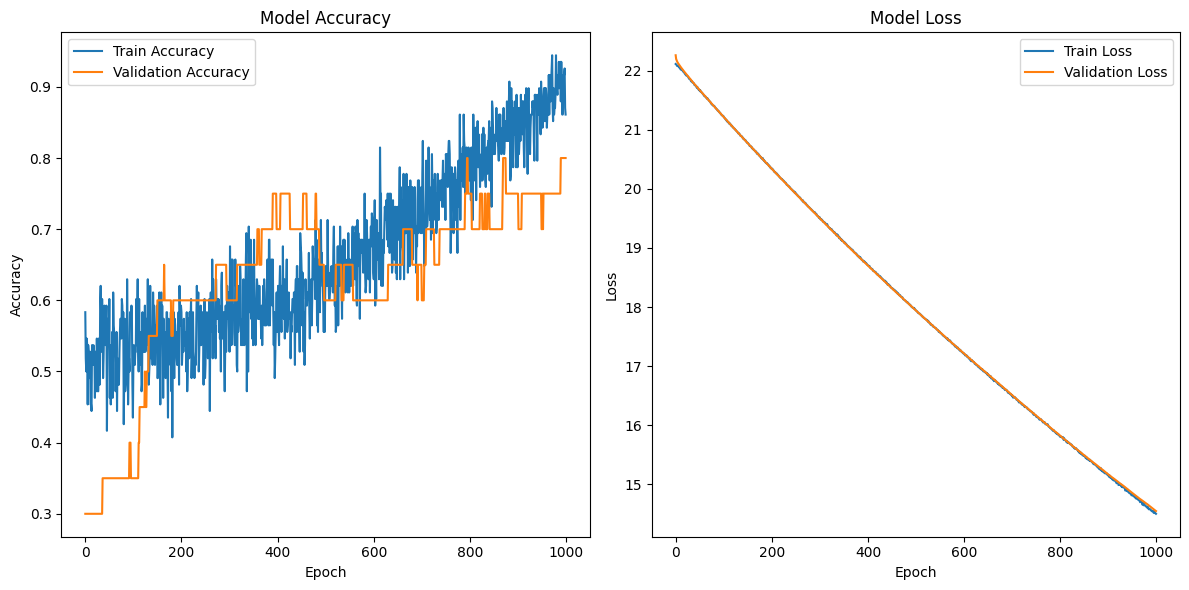

In [ ]:
# Plot training & validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
y_pred = model.predict([X_audio_test, X_text_test, X_visual_test])
y_pred_classes = np.argmax(y_pred, axis=1)

class_names = ['Non-depressed', 'Depressed']
report = classification_report(y_test, y_pred_classes, target_names=class_names)
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
               precision    recall  f1-score   support

Non-depressed       0.62      0.83      0.71         6
    Depressed       0.92      0.79      0.85        14

     accuracy                           0.80        20
    macro avg       0.77      0.81      0.78        20
 weighted avg       0.83      0.80      0.81        20



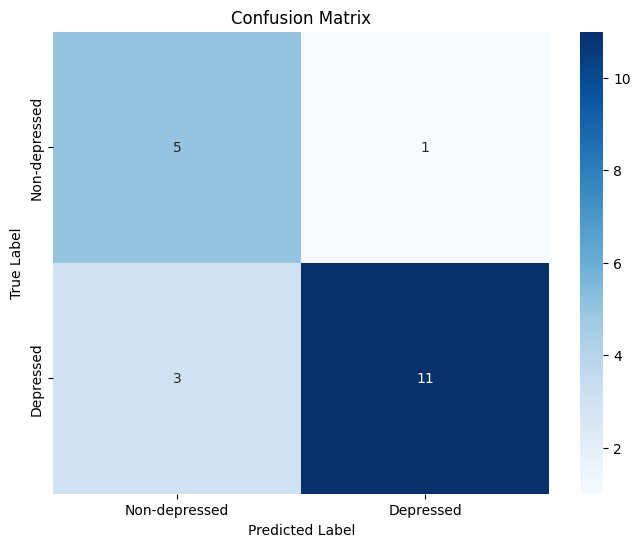

In [ ]:
y_pred_classes = np.argmax(y_pred, axis=1)
conf_matrix = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()